In [1]:
print("Hello World")

Hello World


In [3]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv('DailyDelhiClimateTrain.csv')

In [5]:
df.head(10)

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
5,2013-01-06,7.000000,82.800000,1.480000,1018.000000
6,2013-01-07,7.000000,78.600000,6.300000,1020.000000
7,2013-01-08,8.857143,63.714286,7.142857,1018.714286
8,2013-01-09,14.000000,51.250000,12.500000,1017.000000
9,2013-01-10,11.000000,62.000000,7.400000,1015.666667


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   str    
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), str(1)
memory usage: 57.2 KB


In [12]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [8]:
df.head(5)

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [13]:
df.set_index('date', inplace=True)
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


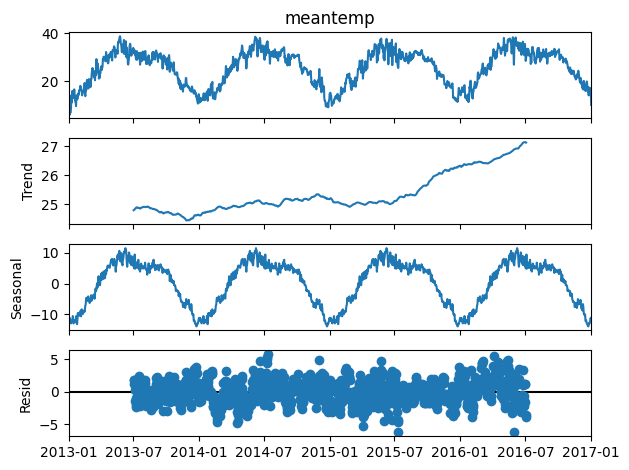

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result = seasonal_decompose(df['meantemp'], model='additive', period=365)

result.plot()
plt.show()

In [15]:
df.head(10)

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000
2013-01-06,7.000000,82.800000,1.480000,1018.000000
2013-01-07,7.000000,78.600000,6.300000,1020.000000
2013-01-08,8.857143,63.714286,7.142857,1018.714286
2013-01-09,14.000000,51.250000,12.500000,1017.000000


In [16]:
df['lag_1'] = df['meantemp'].shift(1)
df['lag_7'] = df['meantemp'].shift(7)
df['lag_30'] = df['meantemp'].shift(30)

In [17]:
df.head(10)

,meantemp,humidity,wind_speed,meanpressure,lag_1,lag_7,lag_30
date,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,NaN,NaN,NaN
2013-01-02,7.400000,92.000000,2.980000,1017.800000,10.000000,NaN,NaN
2013-01-03,7.166667,87.000000,4.633333,1018.666667,7.400000,NaN,NaN
2013-01-04,8.666667,71.333333,1.233333,1017.166667,7.166667,NaN,NaN
2013-01-05,6.000000,86.833333,3.700000,1016.500000,8.666667,NaN,NaN
2013-01-06,7.000000,82.800000,1.480000,1018.000000,6.000000,NaN,NaN
2013-01-07,7.000000,78.600000,6.300000,1020.000000,7.000000,NaN,NaN
2013-01-08,8.857143,63.714286,7.142857,1018.714286,7.000000,10.000000,NaN
2013-01-09,14.000000,51.250000,12.500000,1017.000000,8.857143,7.400000,NaN


In [18]:
df['rolling_mean_7'] = df['meantemp'].rolling(window=7).mean()
df['rolling_mean_30'] = df['meantemp'].rolling(window=30).mean()

In [19]:
df.head(10)

,meantemp,humidity,wind_speed,meanpressure,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
date,,,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,NaN,NaN,NaN,NaN,NaN
2013-01-02,7.400000,92.000000,2.980000,1017.800000,10.000000,NaN,NaN,NaN,NaN
2013-01-03,7.166667,87.000000,4.633333,1018.666667,7.400000,NaN,NaN,NaN,NaN
2013-01-04,8.666667,71.333333,1.233333,1017.166667,7.166667,NaN,NaN,NaN,NaN
2013-01-05,6.000000,86.833333,3.700000,1016.500000,8.666667,NaN,NaN,NaN,NaN
2013-01-06,7.000000,82.800000,1.480000,1018.000000,6.000000,NaN,NaN,NaN,NaN
2013-01-07,7.000000,78.600000,6.300000,1020.000000,7.000000,NaN,NaN,7.604762,NaN
2013-01-08,8.857143,63.714286,7.142857,1018.714286,7.000000,10.000000,NaN,7.441497,NaN
2013-01-09,14.000000,51.250000,12.500000,1017.000000,8.857143,7.400000,NaN,8.384354,NaN


In [20]:
df['day'] = df.index.day
df['month'] = df.index.month
df['year'] = df.index.year
df['day_of_week'] = df.index.dayofweek
df['week_of_year'] = df.index.isocalendar().week

In [21]:
df.head(30)

,meantemp,humidity,wind_speed,meanpressure,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,day,month,year,day_of_week,week_of_year
date,,,,,,,,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,NaN,NaN,NaN,NaN,NaN,1,1,2013,1,1
2013-01-02,7.400000,92.000000,2.980000,1017.800000,10.000000,NaN,NaN,NaN,NaN,2,1,2013,2,1
2013-01-03,7.166667,87.000000,4.633333,1018.666667,7.400000,NaN,NaN,NaN,NaN,3,1,2013,3,1
2013-01-04,8.666667,71.333333,1.233333,1017.166667,7.166667,NaN,NaN,NaN,NaN,4,1,2013,4,1
2013-01-05,6.000000,86.833333,3.700000,1016.500000,8.666667,NaN,NaN,NaN,NaN,5,1,2013,5,1
2013-01-06,7.000000,82.800000,1.480000,1018.000000,6.000000,NaN,NaN,NaN,NaN,6,1,2013,6,1
2013-01-07,7.000000,78.600000,6.300000,1020.000000,7.000000,NaN,NaN,7.604762,NaN,7,1,2013,0,2
2013-01-08,8.857143,63.714286,7.142857,1018.714286,7.000000,10.000000,NaN,7.441497,NaN,8,1,2013,1,2
2013-01-09,14.000000,51.250000,12.500000,1017.000000,8.857143,7.400000,NaN,8.384354,NaN,9,1,2013,2,2


In [22]:
df = df.dropna()

In [23]:
df.head(30)

,meantemp,humidity,wind_speed,meanpressure,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,day,month,year,day_of_week,week_of_year
date,,,,,,,,,,,,,,
2013-01-31,16.200000,65.600000,2.960000,1018.400000,14.714286,13.833333,10.000000,13.949490,12.143929,31,1,2013,3,5
2013-02-01,16.000000,73.000000,2.220000,1016.000000,16.200000,12.250000,7.400000,14.485204,12.430595,1,2,2013,4,5
2013-02-02,16.285714,77.571429,1.328571,1017.142857,16.000000,12.666667,7.166667,15.002211,12.734563,2,2,2013,5,5
2013-02-03,18.000000,65.571429,1.857143,1015.285714,16.285714,12.857143,8.666667,15.736905,13.045675,3,2,2013,6,5
2013-02-04,17.428571,74.285714,11.114286,1014.571429,18.000000,14.833333,6.000000,16.107653,13.426627,4,2,2013,0,6
2013-02-05,16.625000,92.375000,9.725000,1016.375000,17.428571,14.125000,7.000000,16.464796,13.747460,5,2,2013,1,6
2013-02-06,16.666667,71.333333,8.633333,1018.666667,16.625000,14.714286,7.000000,16.743707,14.069683,6,2,2013,2,6
2013-02-07,15.600000,59.400000,10.740000,1018.600000,16.666667,16.200000,8.857143,16.657993,14.294444,7,2,2013,3,6
2013-02-08,14.000000,70.428571,9.257143,1017.142857,15.600000,16.000000,14.000000,16.372279,14.294444,8,2,2013,4,6
